In [ ]:
#CELL 1

In [1]:
!pip install -q mediapipe opencv-python-headless

import cv2
import numpy as np
import mediapipe as mp
import tensorflow as tf
from tensorflow.keras.models import load_model
from google.colab import drive

print("✅ Setup done")

✅ Setup done


In [2]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/dds2.zip'
extract_path = '/content/drive/MyDrive/dds2_extracted'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extracted and saved in Drive")

✅ Extracted and saved in Drive


In [ ]:
import os

base = '/content/drive/MyDrive/dds2_extracted'

for root, dirs, files in os.walk(base):
    print(root)

/content/drive/MyDrive/dds2_extracted
/content/drive/MyDrive/dds2_extracted/Driver Drowsiness Dataset (DDD)
/content/drive/MyDrive/dds2_extracted/Driver Drowsiness Dataset (DDD)/Drowsy
/content/drive/MyDrive/dds2_extracted/Driver Drowsiness Dataset (DDD)/Non Drowsy


In [4]:
import os
import shutil
from tqdm import tqdm

# ✅ Correct dataset path (SET HERE)
DATA_DIR = '/content/drive/MyDrive/dds2_extracted/Driver Drowsiness Dataset (DDD)'

open_src = os.path.join(DATA_DIR, 'Non Drowsy')
closed_src = os.path.join(DATA_DIR, 'Drowsy')

WORK_DIR = '/content/drive/MyDrive/eye_data'

open_dst = os.path.join(WORK_DIR, 'open')
closed_dst = os.path.join(WORK_DIR, 'closed')

os.makedirs(open_dst, exist_ok=True)
os.makedirs(closed_dst, exist_ok=True)

# 🔍 Check paths
if not os.path.exists(open_src) or not os.path.exists(closed_src):
    raise ValueError("❌ Check DATA_DIR path — folders not found")

print("📂 Copying OPEN images...")
for f in tqdm(os.listdir(open_src)):
    src = os.path.join(open_src, f)
    dst = os.path.join(open_dst, f)

    # ✅ avoid duplicate copy
    if not os.path.exists(dst):
        shutil.copy(src, dst)

print("📂 Copying CLOSED images...")
for f in tqdm(os.listdir(closed_src)):
    src = os.path.join(closed_src, f)
    dst = os.path.join(closed_dst, f)

    if not os.path.exists(dst):
        shutil.copy(src, dst)

print("✅ Dataset ready in Drive")

📂 Copying OPEN images...


100%|██████████| 19445/19445 [00:23<00:00, 818.72it/s] 


📂 Copying CLOSED images...


100%|██████████| 22348/22348 [00:13<00:00, 1644.53it/s]

✅ Dataset ready in Drive


In [5]:
import tensorflow as tf

DATA_DIR = '/content/drive/MyDrive/eye_data'

IMG_SIZE = 96
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

print("✅ Dataset loaded")

Found 41793 files belonging to 2 classes.
Using 33435 files for training.
Found 41793 files belonging to 2 classes.
Using 8358 files for validation.
✅ Dataset loaded


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs=base.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model ready")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Model ready


In [ ]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 1200s 1s/step - accuracy: 0.9329 - loss: 0.1735 - val_accuracy: 0.9831 - val_loss: 0.0536
Epoch 2/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 750s 684ms/step - accuracy: 0.9827 - loss: 0.0575 - val_accuracy: 0.9910 - val_loss: 0.0291
Epoch 3/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 721s 664ms/step - accuracy: 0.9856 - loss: 0.0436 - val_accuracy: 0.9939 - val_loss: 0.0169
Epoch 4/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 726s 649ms/step - accuracy: 0.9885 - loss: 0.0351 - val_accuracy: 0.9947 - val_loss: 0.0149
Epoch 5/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 652s 624ms/step - accuracy: 0.9877 - loss: 0.0354 - val_accuracy: 0.9956 - val_loss: 0.0128
Epoch 6/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 599s 573ms/step - accuracy: 0.9908 - loss: 0.0289 - val_accuracy: 0.9963 - val_loss: 0.0112
Epoch 7/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 570s 523ms/step - accuracy: 0.9906 - loss: 0.0272 - val_accuracy: 0.9952 - val_loss: 0.0141
Epoch 8/15
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 563s 524ms/step - accu

In [7]:
import os

SAVE_PATH = '/content/drive/MyDrive/dds_trained_model/'
os.makedirs(SAVE_PATH, exist_ok=True)

model.save(SAVE_PATH + 'drowsiness_model.keras')

print("✅ Model saved permanently in Drive")

✅ Model saved permanently in Drive


In [8]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/dds_trained_model/drowsiness_model.keras')

print("✅ Model loaded")

✅ Model loaded


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


📤 Upload an image...


Saving ddsssss.jpg to ddsssss.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


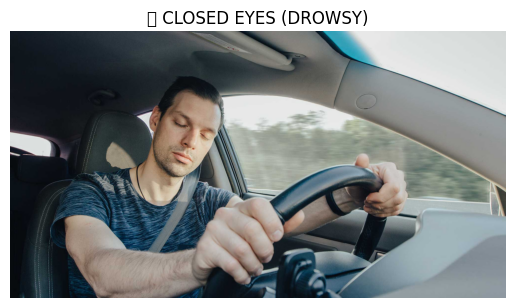

Prediction Score: 0.4498


In [9]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("📤 Upload an image...")
uploaded = files.upload()

IMG_SIZE = 96

for fname in uploaded:

    img = cv2.imread(fname)


    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_resized = img_resized.astype(np.float32) / 255.0
    img_resized = np.expand_dims(img_resized, axis=0)

    pred = model.predict(img_resized)[0][0]

    if pred > 0.5:
        label = "🟢 OPEN EYES (NOT DROWSY)"
    else:
        label = "🔴 CLOSED EYES (DROWSY)"

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(label)
    plt.axis('off')
    plt.show()

    print(f"Prediction Score: {pred:.4f}")